<font color="#6E6E6E"><h1 align="left">**Predicción de demanda**</h1></font>

<h2 align="left">Manuel Sánchez-Montañés</h2>

<font color="#6E6E6E"><h2 align="left">manuel.smontanes@gmail.com</h2></font>

**Datos: Carlos Rosado**

In [1]:
#!pip install gitdir
#!gitdir https://github.com/uchidalab/time_series_augmentation/tree/master/utils

In [2]:
import utils.augmentation as aug
import pandas as pd
import numpy as np

/Users/manuel/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/manuel/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# funciones de apoyo:

from IPython.display import display_html
from matplotlib.ticker import MaxNLocator
from my_utils_series_temporales import NAN, enventanar, my_dfs_display, info_enventanado

def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse)
    plt.plot(1+np.arange(len(val_mse)), val_mse)
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

## <font color="#CA3532"> **Carga de datos**

In [4]:
data = pd.read_csv('datos_pasajeros.csv')
data.head(20)

,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,1,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,0,2767,0,0
5,2015-01-06,1,1,1342,0,1
6,2015-01-07,1,0,3867,0,2
7,2015-01-08,1,0,3904,1,3
8,2015-01-09,1,0,3678,1,4
9,2015-01-10,1,0,2631,1,5


In [6]:
data2 = data.copy()
fechas_aux = data2.index
data2.loc[fechas_aux[:-1], "festivo"] = data2.loc[fechas_aux[1:], "festivo"].values
data2

,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,0,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,1,2767,0,0
...,...,...,...,...,...,...
785,2017-02-24,2,0,4199,2,4
786,2017-02-25,2,0,2534,2,5
787,2017-02-26,2,0,1816,2,6
788,2017-02-27,2,0,3990,2,0


In [7]:
data.shape

(790, 6)

In [8]:
# npasajeros: variable endógena
# resto: variables exógenas, que también son "variables calendario"

In [9]:
data.dtypes

fecha            str
mes            int64
festivo        int64
npasajeros     int64
semana_mes     int64
day_of_week    int64
dtype: object

In [10]:
data.values[:5,0]

array(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
       '2015-01-05'], dtype=object)

In [11]:
data["fecha"] = pd.to_datetime(data["fecha"])

In [12]:
data["fecha"].values[:5]

array(['2015-01-01T00:00:00.000000', '2015-01-02T00:00:00.000000',
       '2015-01-03T00:00:00.000000', '2015-01-04T00:00:00.000000',
       '2015-01-05T00:00:00.000000'], dtype='datetime64[us]')

In [13]:
fechas = data["fecha"].values

In [14]:
# ¿Todas las fechas van de 1 día en 1 día?

aux1 = fechas[1:] # fechas de la segunda a la última
aux2 = fechas[:-1] # fechas de la primera a la penúltima

np.unique(aux1 - aux2)

array([86400000000], dtype='timedelta64[us]')

In [15]:
# nanosegundos que tiene un día:
60*60*24*1000000000

86400000000000

In [16]:
# -> la diferencia entre una fecha y la anterior es siempre 1 día

In [17]:
# hay nulls?
data.isna().sum()

fecha          0
mes            0
festivo        0
npasajeros     0
semana_mes     0
day_of_week    0
dtype: int64

In [18]:
target  = data["npasajeros"].values
mes     = data["mes"].values
festivo = data["festivo"].values
semana  = data["semana_mes"].values
day_of_week = data["day_of_week"].values

In [19]:
# L,M,X,J,V, S (NAN), D (NAN)

# ENTRADA A MODELO:
# L1, M1, X1, J1, V1, L2, M2, X2, J2, V2
# SALIDA MODELO:
# L3, M3, X3, J3, V3

# ENTRADA A MODELO:
# L2, M2, X2, J2, V2, L3, M3, X3, J3, V3
# SALIDA MODELO:
# L4, M4, X4, J4, V4


# PASAJEROS:
# L, M, X, J, V -> PREDIGO S
# M, X, J, V, S -> PREDIGO D
# X, J, V, S, D -> PREDIGO L2

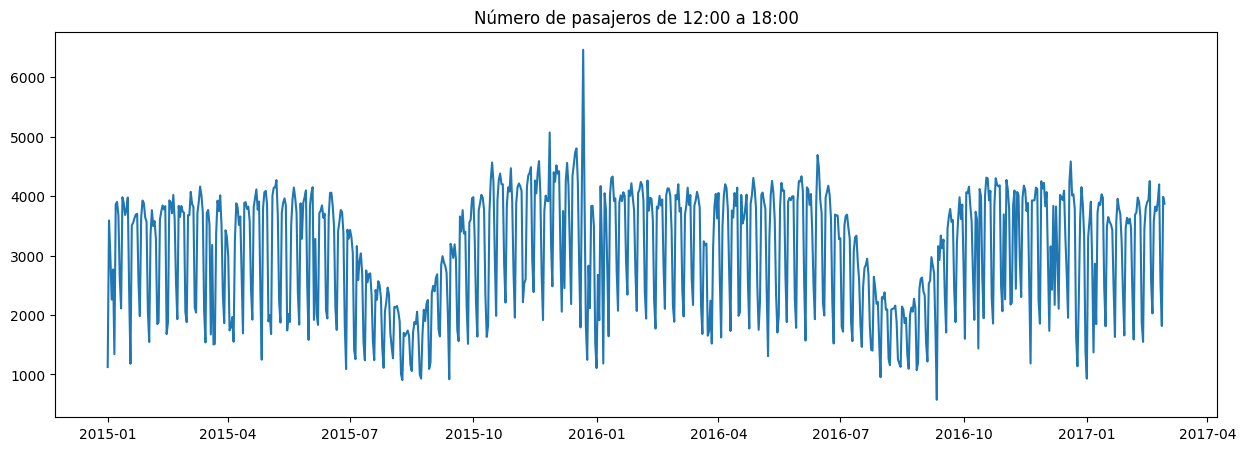

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(fechas, target)
plt.title("Número de pasajeros de 12:00 a 18:00");

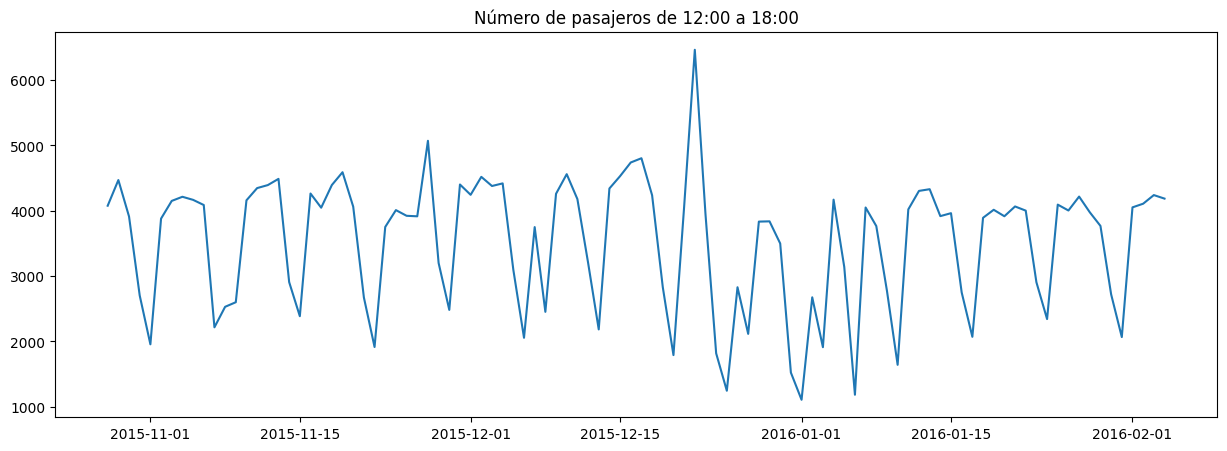

In [21]:
plt.figure(figsize=(15,5))
plt.plot(fechas[300:400], target[300:400])
plt.title("Número de pasajeros de 12:00 a 18:00");

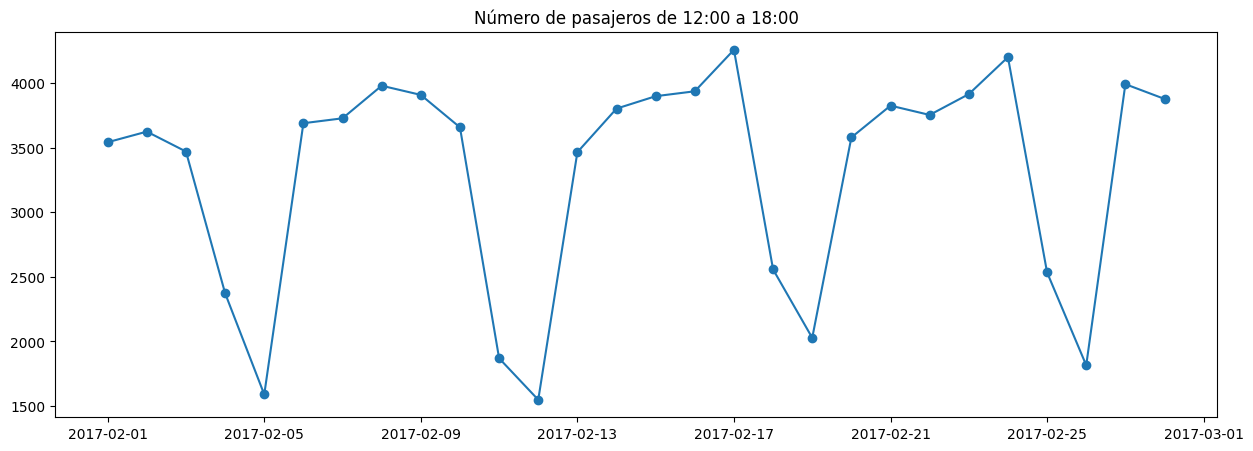

In [22]:
plt.figure(figsize=(15,5))
plt.plot(fechas[-28:], target[-28:], "-o")
plt.title("Número de pasajeros de 12:00 a 18:00");

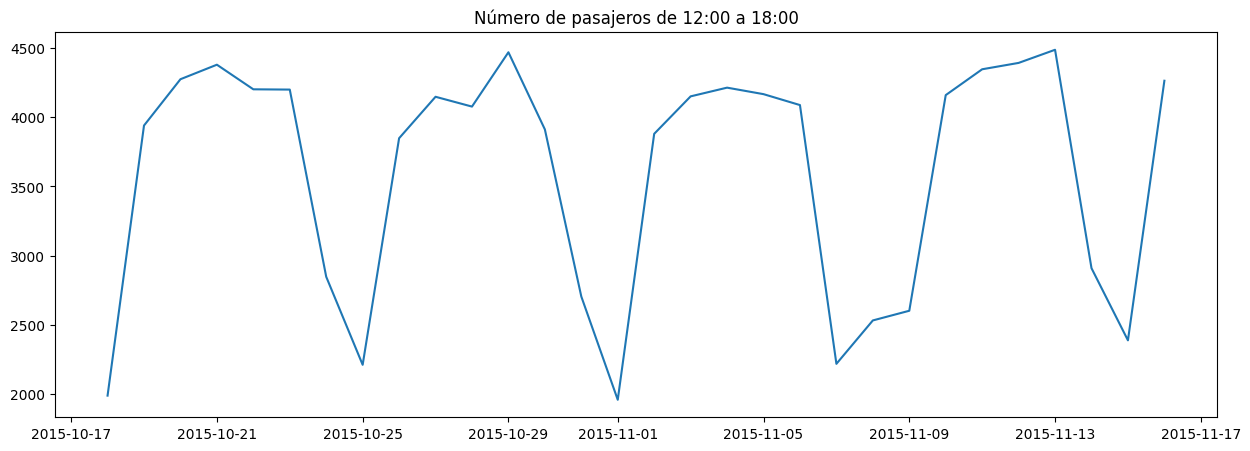

In [23]:
plt.figure(figsize=(15,5))
plt.plot(fechas[290:320], target[290:320])
plt.title("Número de pasajeros de 12:00 a 18:00");

In [24]:
# benchmark

# Benchmarks: modelos básicos

1. Modelo que siempre predice la media
2. Modelo que predice para mañana lo mismo que hoy (persistente a 1 día)
3. Modelo que predice para mañana lo mismo que hace 1 semana (persistente a 1 semana)
4. Modelo que predice para mañana lo mismo que hace 1 año (persistente a 1 año)

In [25]:
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score as R2 # "coeficiente de determinación". Máximo: +1 (perfecto)

In [26]:
# correlación pearson (r2) entre altura(cm) y altura(m) = +1
# coeficiente de determinación (R2) entre altura(cm) y altura(m) << 0

In [27]:
R2(target, target)

1.0

In [28]:
R2(target, 100*target)

-102595.6943353768

In [29]:
# Modelo 0: predecir siempre lo mismo (la media)

# Modelo más sencillo que puedo construir 1: "Modelo persistente"
# Es un modelo que predice para mañana lo mismo que hoy

In [30]:
# modelo 0:

media = target.mean()

In [31]:
# root MSE (raíz cuadrada del MSE)

np.sqrt(MSE(target, media*np.ones(len(target))))

996.2852958245312

In [32]:
# modelo persistente a 1 día:

a_predecir = target[1:]
datos_base = target[:-1]
np.sqrt(MSE(a_predecir, datos_base))

988.4204417057293

In [33]:
# R2 = 1 - MSE / var(target)

# R2 del modelo que predice siempre la media:
R2(target, media*np.ones(len(target)))

0.0

In [34]:
1 - MSE(target, media*np.ones(len(target))) / target.var()

0.0

In [35]:
# R2 del modelo persistente a 1 día:
R2(a_predecir, datos_base)

0.012222134392111283

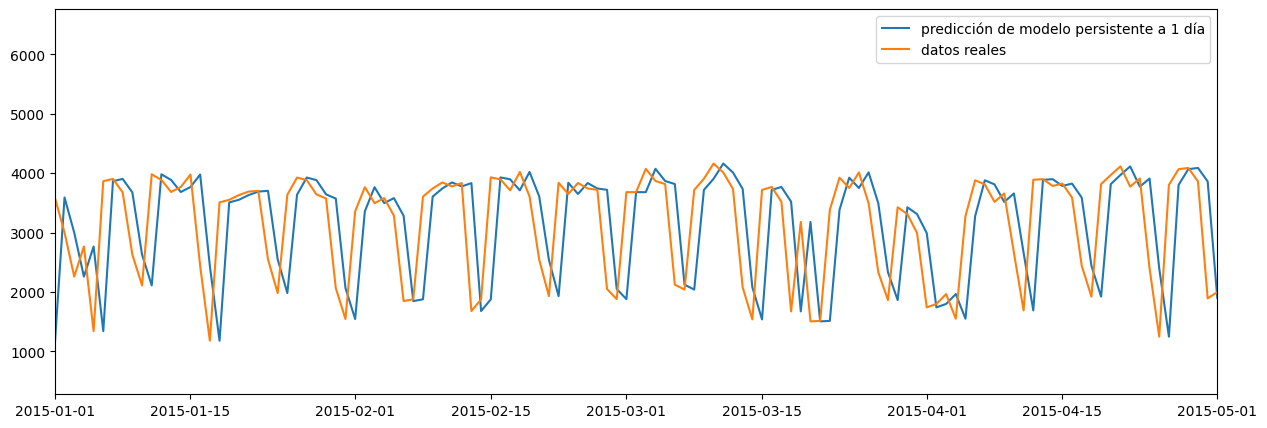

In [36]:
plt.figure(figsize=(15,5))
plt.plot(fechas[:-1], datos_base, label="predicción de modelo persistente a 1 día")
plt.plot(fechas[:-1], a_predecir, label="datos reales")
plt.xlim([fechas[0], fechas[120]])
plt.legend();

0.5871778047256262


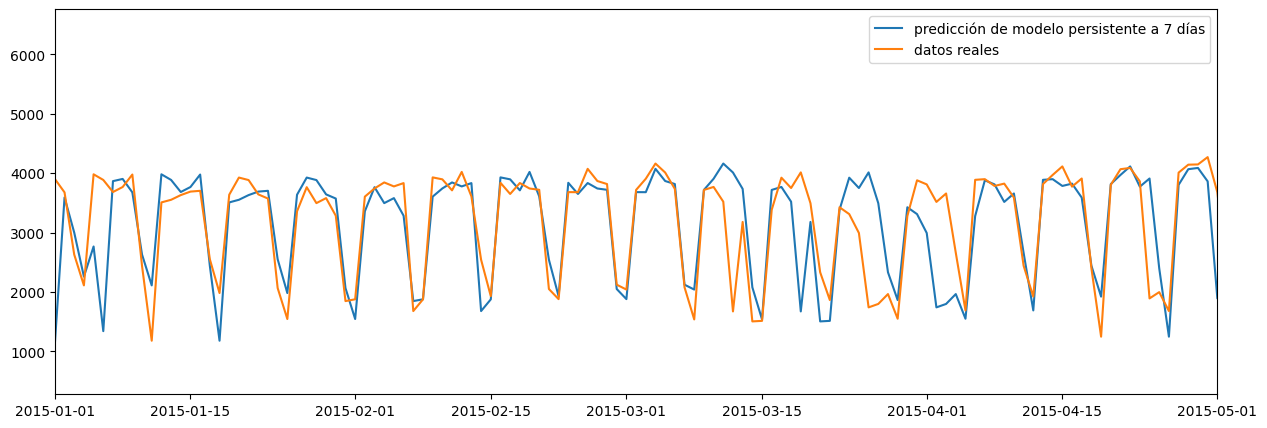

In [37]:
# modelo persistente a 7 días:

a_predecir = target[7:]
datos_base = target[:-7]
print(R2(a_predecir, datos_base))
plt.figure(figsize=(15,5))
plt.plot(fechas[:-7], datos_base, label="predicción de modelo persistente a 7 días")
plt.plot(fechas[:-7], a_predecir, label="datos reales")
plt.xlim([fechas[0], fechas[120]])
plt.legend();

0.35198273494911625


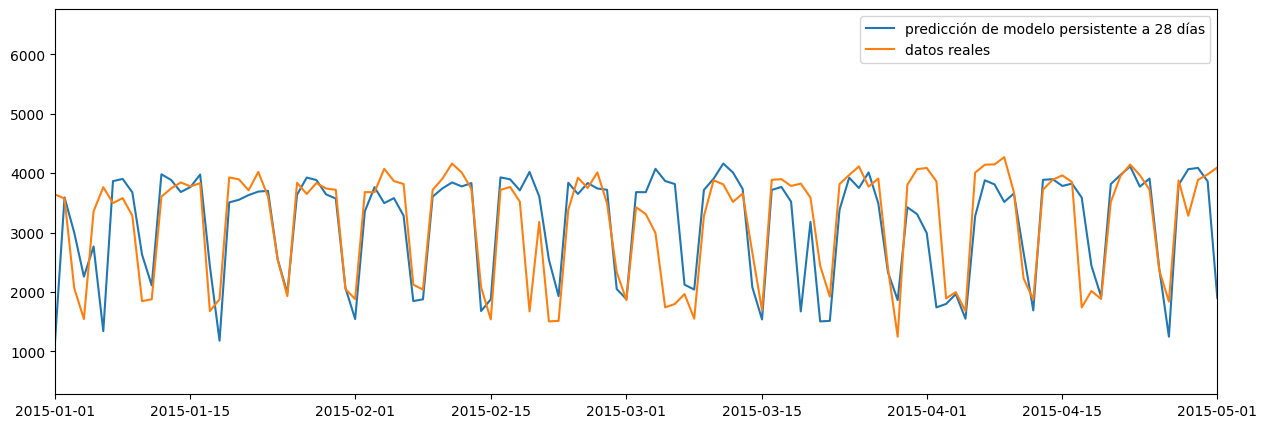

In [38]:
# modelo persistente a 7*4 días:

a_predecir = target[28:]
datos_base = target[:-28]
print(R2(a_predecir, datos_base))
plt.figure(figsize=(15,5))
plt.plot(fechas[:-28], datos_base, label="predicción de modelo persistente a 28 días")
plt.plot(fechas[:-28], a_predecir, label="datos reales")
plt.xlim([fechas[0], fechas[120]])
plt.legend();

0.5415758633121963


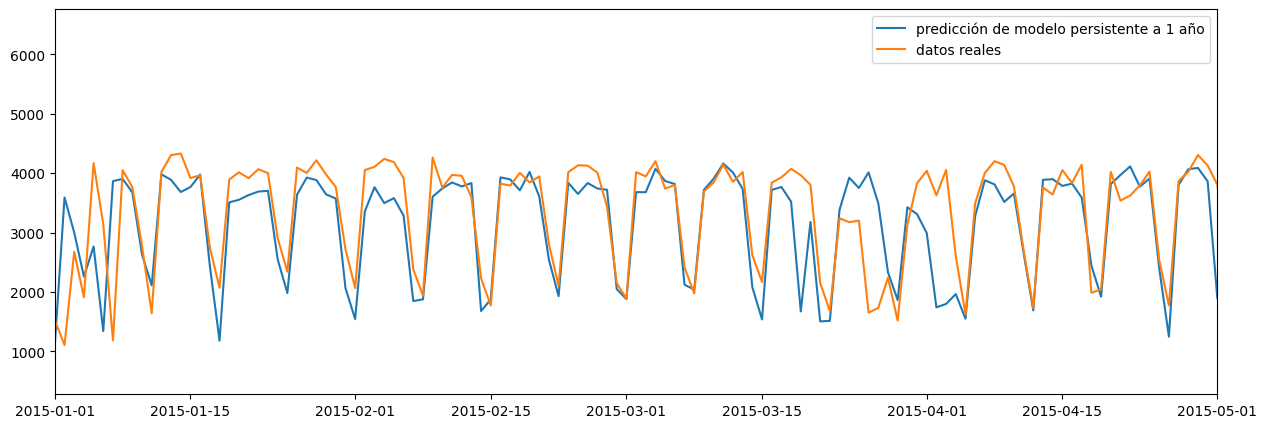

In [39]:
# modelo persistente a 7*52 días:
n = 7*52

a_predecir = target[n:]
datos_base = target[:-n]
print(R2(a_predecir, datos_base))
plt.figure(figsize=(15,5))
plt.plot(fechas[:-n], datos_base, label="predicción de modelo persistente a 1 año")
plt.plot(fechas[:-n], a_predecir, label="datos reales")
plt.xlim([fechas[0], fechas[120]])
plt.legend();

In [40]:
target.min(), target.max()

(574, 6465)

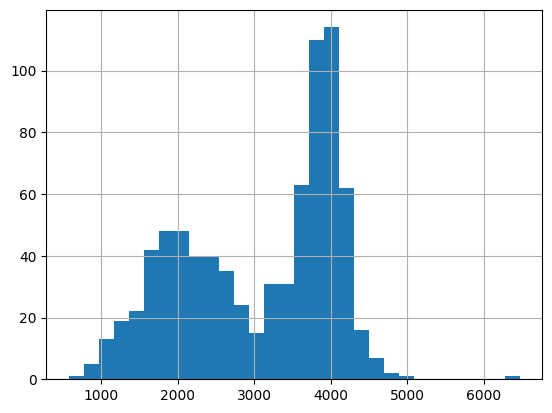

In [41]:
data["npasajeros"].hist(bins=30);

In [42]:
# es una distribución bimodal

In [43]:
data.set_index("fecha", inplace=True)

In [44]:
data

,mes,festivo,npasajeros,semana_mes,day_of_week
fecha,,,,,
2015-01-01,1,1,1125,0,3
2015-01-02,1,0,3592,0,4
2015-01-03,1,0,3001,0,5
2015-01-04,1,0,2260,0,6
2015-01-05,1,0,2767,0,0
...,...,...,...,...,...
2017-02-24,2,0,4199,2,4
2017-02-25,2,0,2534,2,5
2017-02-26,2,0,1816,2,6


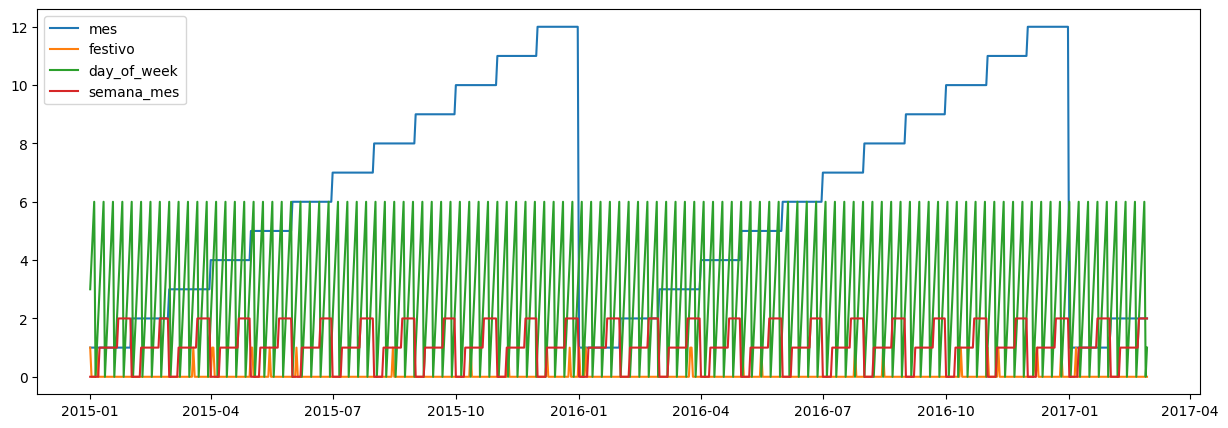

In [45]:
plt.figure(figsize=(15,5))
plt.plot(data["mes"], label="mes")
plt.plot(data["festivo"], label="festivo")
plt.plot(data["day_of_week"], label="day_of_week")
plt.plot(data["semana_mes"], label="semana_mes")
plt.legend();

In [46]:
# DOS SCRIPTS:
# script construcción: construyes, validas y grabas el modelo
# get_dummies (pandas): tengo tantos dummies como categorías. 12 dummies para mes (si en el dataset hay 12 meses al menos)

# script de PRODUCCIÓN:
# script que:
#   carga el modelo entrenado en construcción
#   carga los datos exógenos de los días a predecir
#   transforma variables igual que en CONSTRUCCIÓN, y aplica modelo

# Punto de partición training-test:

In [47]:
train_perc = .8 # 80%

print(len(data))
punto_corte = int(len(data)*train_perc)
punto_corte

790


632

In [48]:
# reservamos un año entero para test:
#punto_corte = len(data) - 365
#punto_corte

# Normalización del target:

In [49]:
media_pasajeros = target[:punto_corte].mean() # media en training
std_pasajeros   = target[:punto_corte].std()  # std en training

def transform(x):
    return (x - media_pasajeros) / std_pasajeros # "Z-score"

def inverse_transform(xp):
    return std_pasajeros*xp + media_pasajeros

# Regla de oro: las estadísticas para normalizar solo se pueden calcular con datos de training

target_transf     = transform(target)
target_recuperado = inverse_transform(target_transf)
print(target[:5])
print(target_recuperado[:5])

[1125 3592 3001 2260 2767]
[1125. 3592. 3001. 2260. 2767.]


In [50]:
target_transf[:punto_corte].mean(), target_transf[:punto_corte].std()

(-3.37282944189921e-17, 1.0)

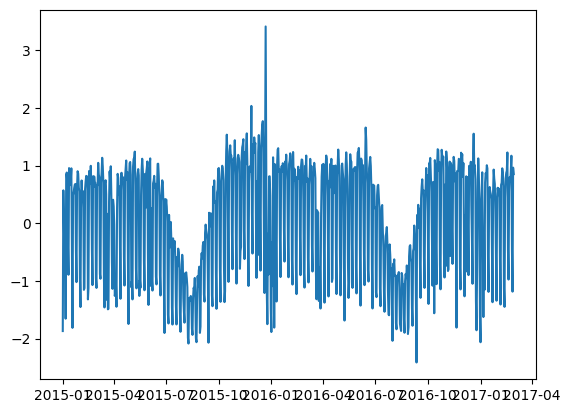

In [51]:
plt.plot(fechas, target_transf);

In [52]:
# LSTM. Entrada: (Número ventanas, Tamaño ventana (número steps), Número variables por step)

In [53]:
# solo uso para predecir pasajeros y día de la semana
data[["npasajeros", "day_of_week"]][:5]

,npasajeros,day_of_week
fecha,,
2015-01-01,1125,3
2015-01-02,3592,4
2015-01-03,3001,5
2015-01-04,2260,6
2015-01-05,2767,0


In [54]:
# Tamaño ventana = 2

# Primera ventana: X=[[1125, 3], [3592, 4]]. Target a predecir: y=3001
# Segunda ventana: X=[[3592, 4], [3001, 5]]. Target a predecir: y=2260
# Tercera ventana: X=[[3001, 5], [2260, 6]]. Target a predecir: y=2767

# Hasta aquí sería un dataset con X.shape = (3, 2, 2)

In [55]:
# Idea: 5 entradas
# input0: pasajeros
# input1: festivo
# input2: mes (empezando desde 0, ya que las categorías en capa embedding empiezan en 0)
# input3: semana (empezando desde 0)
# input4: day_of_week (empezando desde 0)

mes.min(), mes.max(), semana.min(), semana.max(), day_of_week.min(), day_of_week.max()

(1, 12, 0, 2, 0, 6)

In [56]:
mes = mes - 1

In [68]:
W = 7 # ventana de entrada

# enventano pasajeros:
series0         = [target_transf]
se_saben_antes0 = [False]
X0, y = enventanar(series0, target=0,
                   se_saben_antes=se_saben_antes0, W_in=W)

# enventano festivo:
series1         = [festivo]
se_saben_antes1 = [True]
X1, _ = enventanar(series1, target=0,
                   se_saben_antes=se_saben_antes1, W_in=W)

# enventano mes:
series2         = [mes]
se_saben_antes2 = [True]
X2, _ = enventanar(series2, target=0,
                   se_saben_antes=se_saben_antes2, W_in=W)

# enventano semana:
series3         = [semana]
se_saben_antes3 = [True]
X3, _ = enventanar(series3, target=0,
                   se_saben_antes=se_saben_antes3, W_in=W)

# enventano day_of_week:
series4         = [day_of_week]
se_saben_antes4 = [True]
X4, _ = enventanar(series4, target=0,
                   se_saben_antes=se_saben_antes4, W_in=W)

In [69]:
X0.shape, X1.shape, X2.shape, X3.shape, X4.shape, y.shape

((790, 7, 1), (790, 7, 1), (790, 7, 1), (790, 7, 1), (790, 7, 1), (790,))

In [70]:
# conjuntos de ventanas para training:
X0_train = X0[W:punto_corte]
X1_train = X1[W:punto_corte]
X2_train = X2[W:punto_corte]
X3_train = X3[W:punto_corte]
X4_train = X4[W:punto_corte]
y_train = y[W:punto_corte]

# resto de parámetros para training:
target_train = target[W:punto_corte]
fechas_train = fechas[W:punto_corte]

# ventanas para test:
X0_test = X0[punto_corte:]
X1_test = X1[punto_corte:]
X2_test = X2[punto_corte:]
X3_test = X3[punto_corte:]
X4_test = X4[punto_corte:]
y_test = y[punto_corte:]

# resto de parámetros para test:
target_test = target[punto_corte:]
fechas_test = fechas[punto_corte:]

In [71]:
X0_train.shape, X1_train.shape, X2_train.shape, X3_train.shape, X4_train.shape, y_train.shape

((625, 7, 1), (625, 7, 1), (625, 7, 1), (625, 7, 1), (625, 7, 1), (625,))

In [72]:
X0_test.shape, X1_test.shape, X2_test.shape, X3_test.shape, X4_test.shape, y_test.shape

((158, 7, 1), (158, 7, 1), (158, 7, 1), (158, 7, 1), (158, 7, 1), (158,))

# Construcción del modelo a 1 día

In [109]:
from keras import Model
from keras.layers import LSTM, GRU, Dense, Embedding, Input, concatenate
from keras.callbacks import ModelCheckpoint # me permite grabar automáticamente a fichero el
# modelo mejor hasta ahora en validación

In [110]:
X0.shape[1:]

(7, 1)

In [128]:
dim_embedding = 2

# inputs de variables no categóricas o categóricas de 2 clases:
input0 = Input(shape=(W,1), name="target_transf")
input1 = Input(shape=(W,1), name="festivo")

# inputs de variables categóricas con más de 2 clases:
input2 = Input(shape=W, name="mes")
input3 = Input(shape=W, name="semana")
input4 = Input(shape=W, name="day_of_week")

# embeddings de variables categóricas con más de 2 clases:
embedding2 = Embedding(input_dim=12, output_dim=dim_embedding, name="embedding_mes")(input2)
embedding3 = Embedding(input_dim=3, output_dim=dim_embedding, name="embedding_semana")(input3)
embedding4 = Embedding(input_dim=7, output_dim=dim_embedding, name="embedding_day_of_week")(input4)

# concateno:
aux1 = concatenate([input0, input1, embedding2, embedding3, embedding4])

aux2 = GRU(5)(aux1)
aux3 = Dense(1)(aux2)

model = Model(inputs=[input0, input1, input2, input3, input4], outputs=aux3)

In [129]:
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 mes (InputLayer)            [(None, 7)]                  0         []                            
                                                                                                  
 semana (InputLayer)         [(None, 7)]                  0         []                            
                                                                                                  
 day_of_week (InputLayer)    [(None, 7)]                  0         []                            
                                                                                                  
 target_transf (InputLayer)  [(None, 7, 1)]               0         []                            
                                                                                            

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 mes (InputLayer)            [(None, 7)]                  0         []                            
                                                                                                  
 semana (InputLayer)         [(None, 7)]                  0         []                            
                                                                                                  
 day_of_week (InputLayer)    [(None, 7)]                  0         []                            
                                                                                                  
 target_transf (InputLayer)  [(None, 7, 1)]               0         []                            
                                                                                            

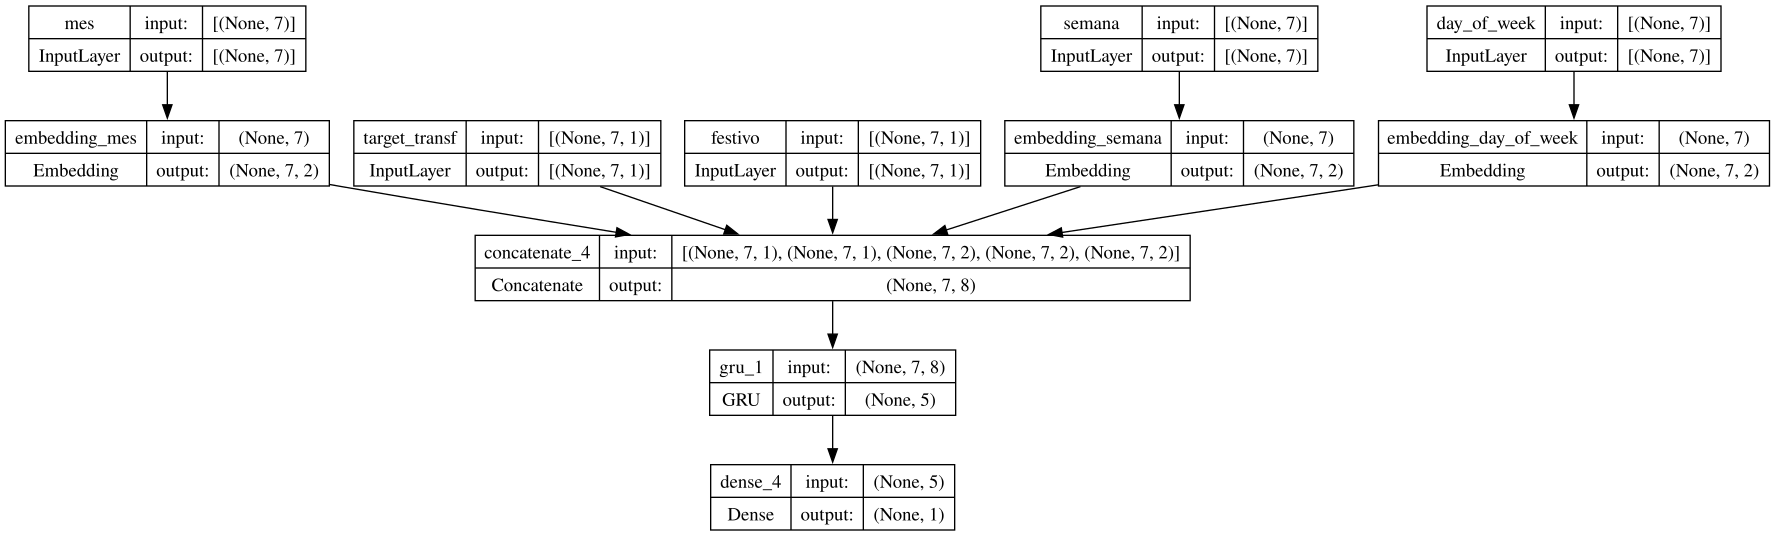

In [130]:
model.summary()

from IPython.display import SVG
from keras.utils import model_to_dot
display(SVG(model_to_dot(model,show_shapes=True).create(prog='dot', format='svg')))

In [131]:
# Adam: más agresivo (acelera / frena el learning_rate)
# RMSProp: más suave
# SGD: "Stochastic Gradient Descend": learning_rate es constante

#model.compile(loss="mean_squared_error", optimizer="adam")
#model.compile(loss="mean_squared_error", optimizer="rmsprop")
model.compile(loss="mean_squared_error", optimizer="sgd")

In [132]:
epochs = 4000
#batch_size = 64
batch_size = 128
Nval = 200

losses_tr = []
losses_va = []
modelpath = "best_model.h5"
checkpoint = ModelCheckpoint(modelpath, monitor="val_loss", verbose=2, save_best_only=True)
X0_tr = X0_train[:-Nval]
X1_tr = X1_train[:-Nval]
X2_tr = X2_train[:-Nval]
X3_tr = X3_train[:-Nval]
X4_tr = X4_train[:-Nval]
y_tr  = y_train[:-Nval]

X0_va = X0_train[-Nval:]
X1_va = X1_train[-Nval:]
X2_va = X2_train[-Nval:]
X3_va = X3_train[-Nval:]
X4_va = X4_train[-Nval:]
y_va = y_train[-Nval:]


Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 0.05076

Epoch 1: val_loss did not improve from 

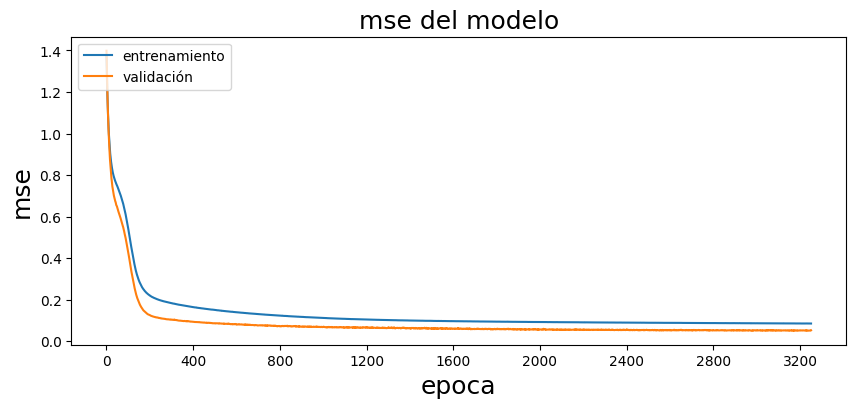


Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 

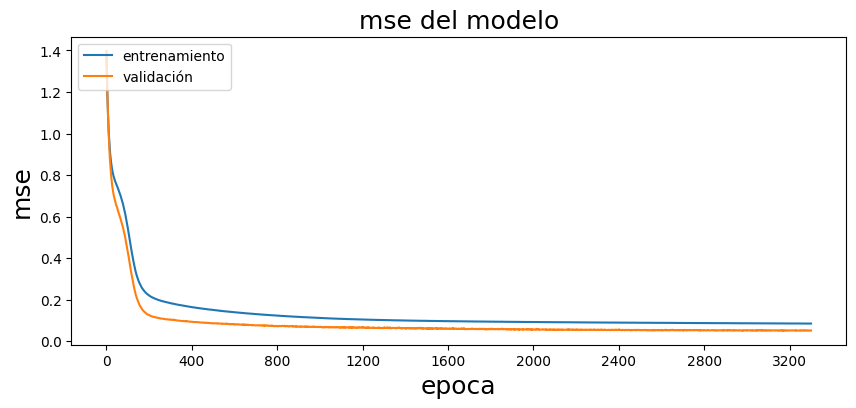


Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 

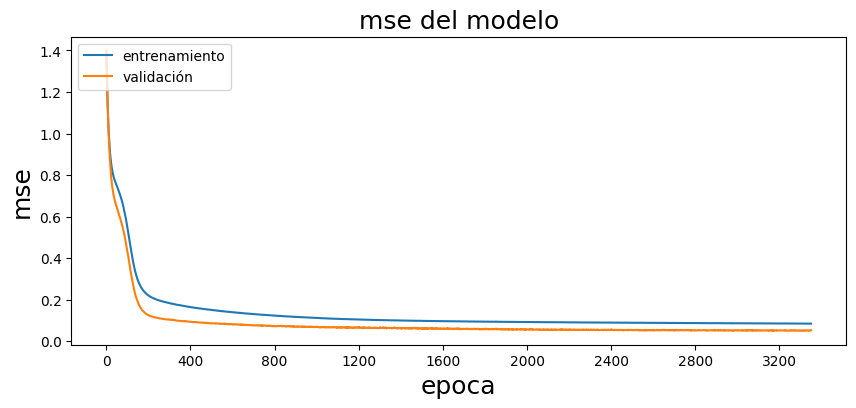


Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 0.05074

Epoch 1: val_loss did not improve from 

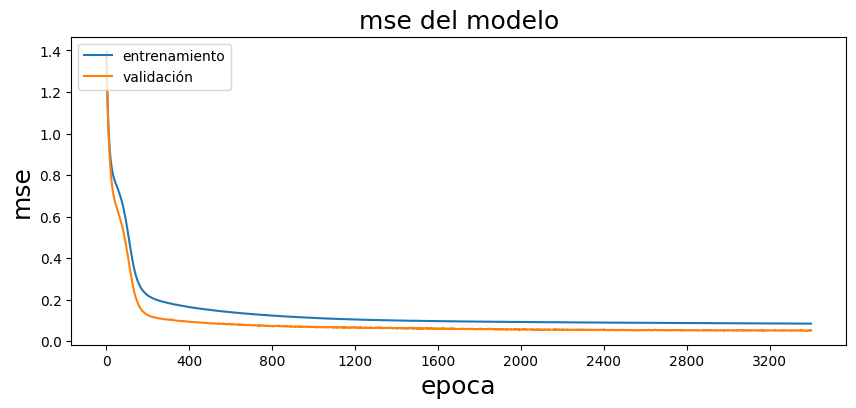


Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 

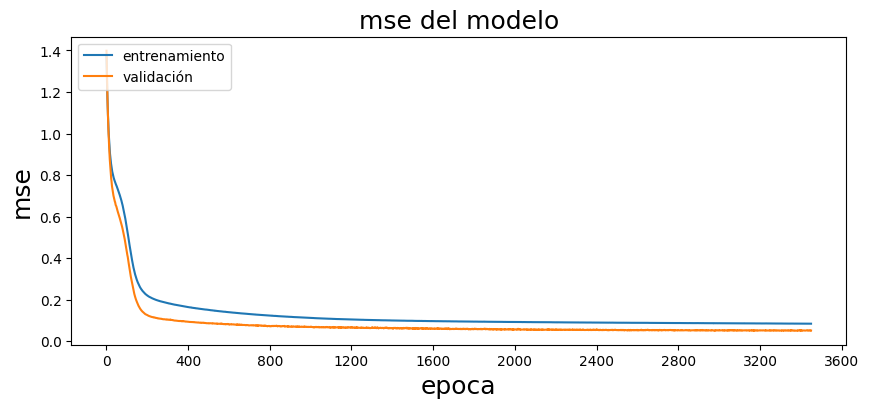


Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 

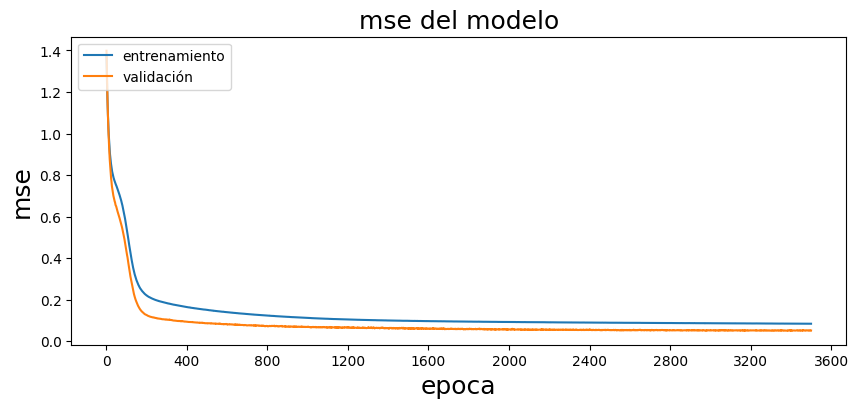


Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 

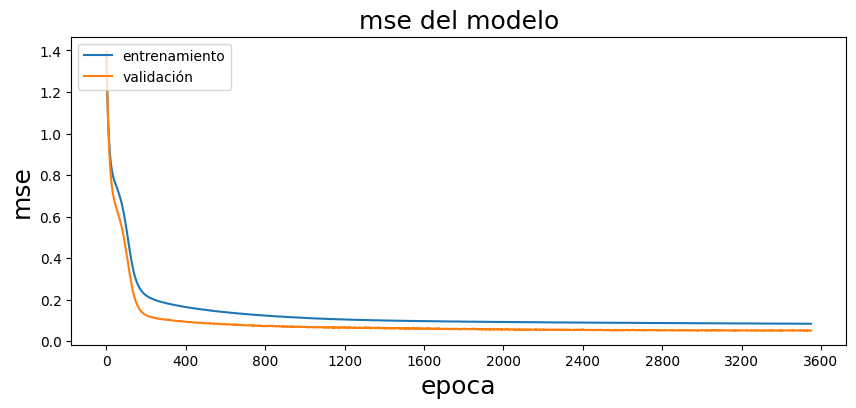


Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss did not improve from 0.05055

Epoch 1: val_loss improved from 0.05055 to 0.05050, saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoc

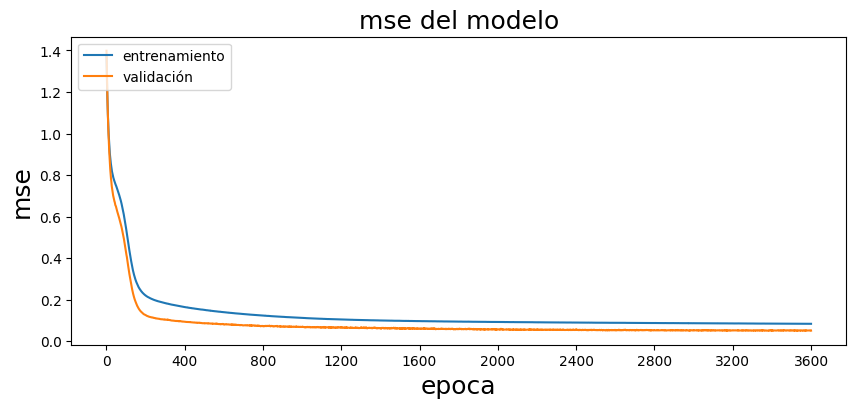


Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 

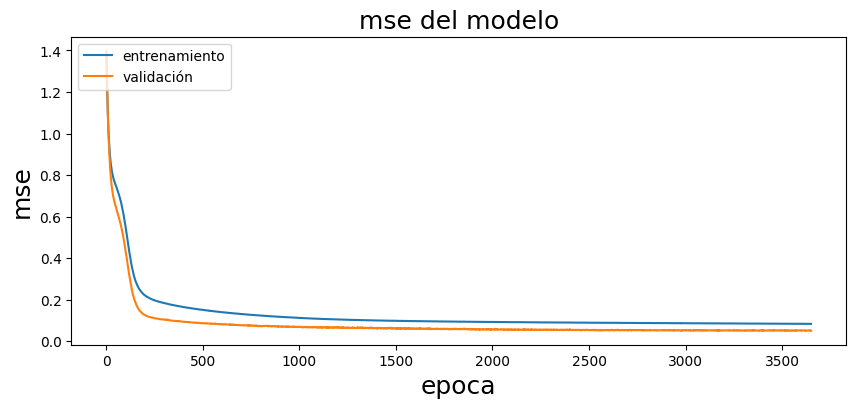


Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 0.05050

Epoch 1: val_loss did not improve from 

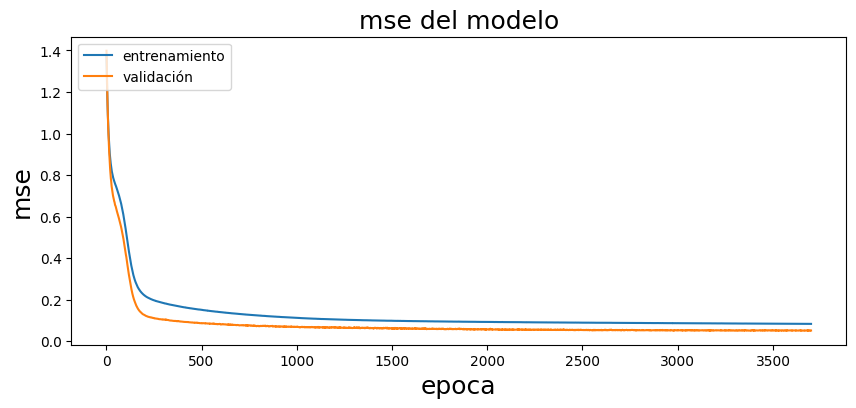


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

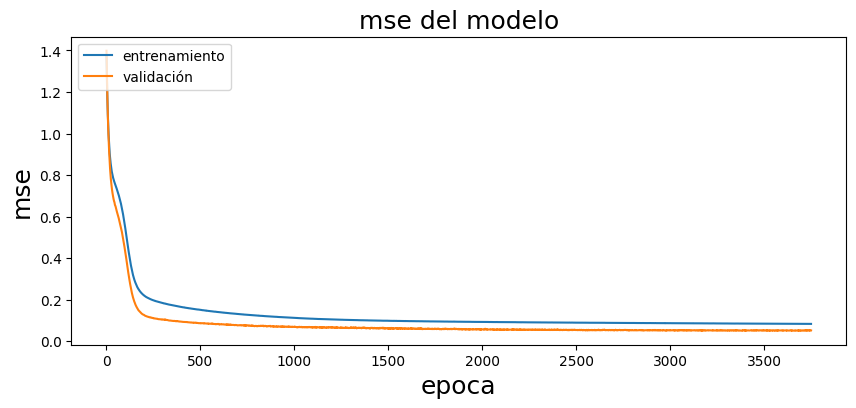


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

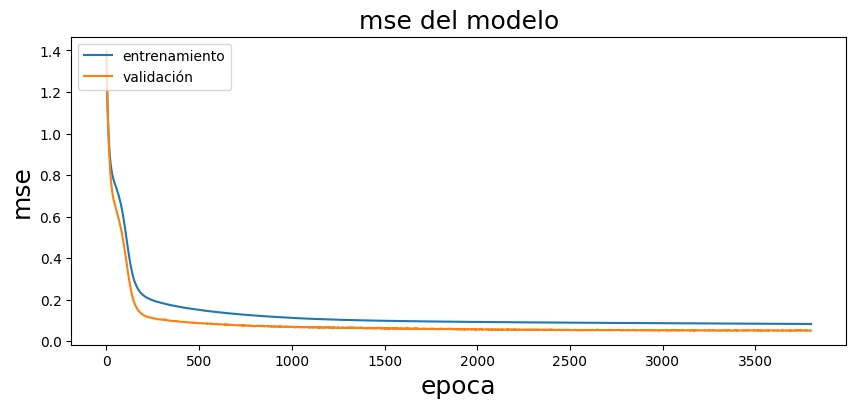


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

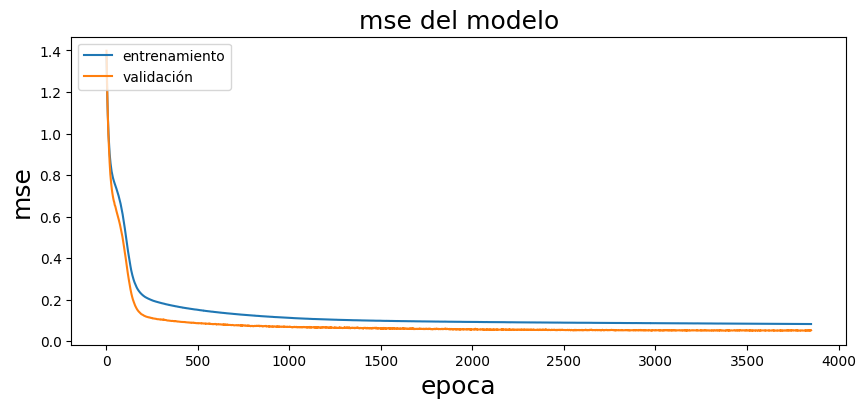


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

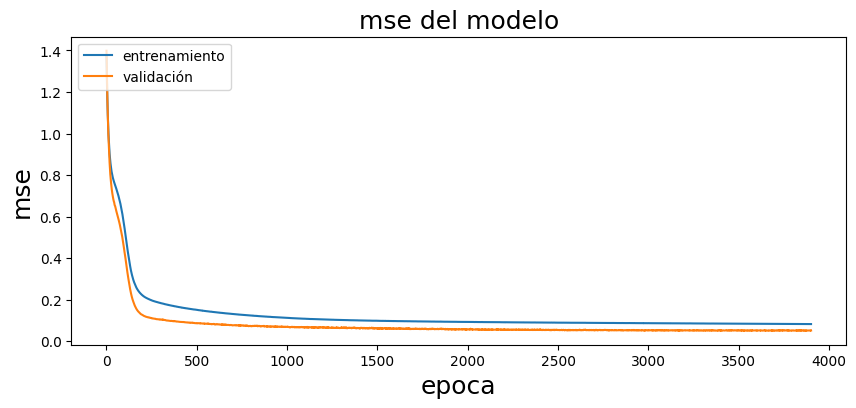


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

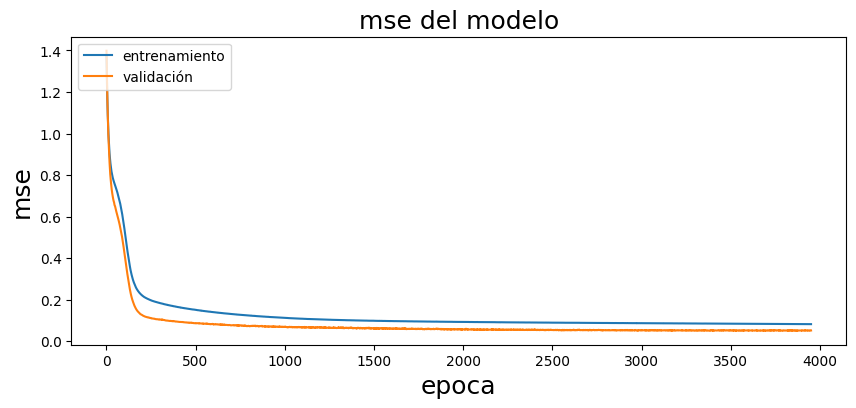


Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 0.05030

Epoch 1: val_loss did not improve from 

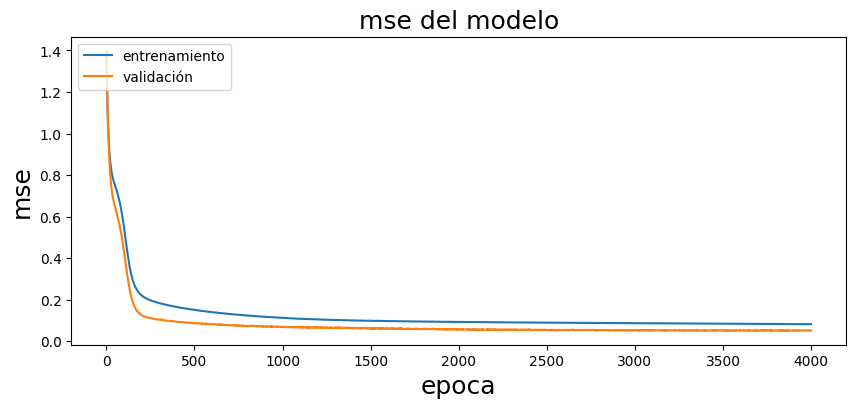

In [137]:
datos_tr = {
    "target_transf": X0_tr,
    "festivo": X1_tr,
    "mes": X2_tr,
    "semana": X3_tr,
    "day_of_week": X4_tr
}

datos_va = {
    "target_transf": X0_va,
    "festivo": X1_va,
    "mes": X2_va,
    "semana": X3_va,
    "day_of_week": X4_va
}

for e in range(epochs):
    history = model.fit(datos_tr, y_tr, batch_size=batch_size, epochs=1, callbacks=[checkpoint],
                        verbose=0, validation_data=(datos_va, y_va))
    losses_tr.append(history.history["loss"][0]) # mse en training en la época
    losses_va.append(history.history["val_loss"][0]) # mse en validación en la época

    if (e+1)%50 == 0: # hago gráfica cada 50 épocas:
        grafica_entrenamiento(losses_tr, losses_va)

In [138]:
from keras.models import load_model

model = load_model(modelpath)

In [139]:
datos_train = {
    "target_transf": X0_train,
    "festivo": X1_train,
    "mes": X2_train,
    "semana": X3_train,
    "day_of_week": X4_train
}

y_train_pred = model.predict(datos_train, verbose=0).flatten()
target_train_pred = inverse_transform(y_train_pred).round()
target_train_pred[:5]

array([3944., 3901., 2388., 1797., 3902.], dtype=float32)

In [140]:
datos_test = {
    "target_transf": X0_test,
    "festivo": X1_test,
    "mes": X2_test,
    "semana": X3_test,
    "day_of_week": X4_test
}

y_test_pred = model.predict(datos_test, verbose=0).flatten()
target_test_pred = inverse_transform(y_test_pred).round()
target_test_pred[:5]

array([2234., 1716., 3739., 3649., 3718.], dtype=float32)

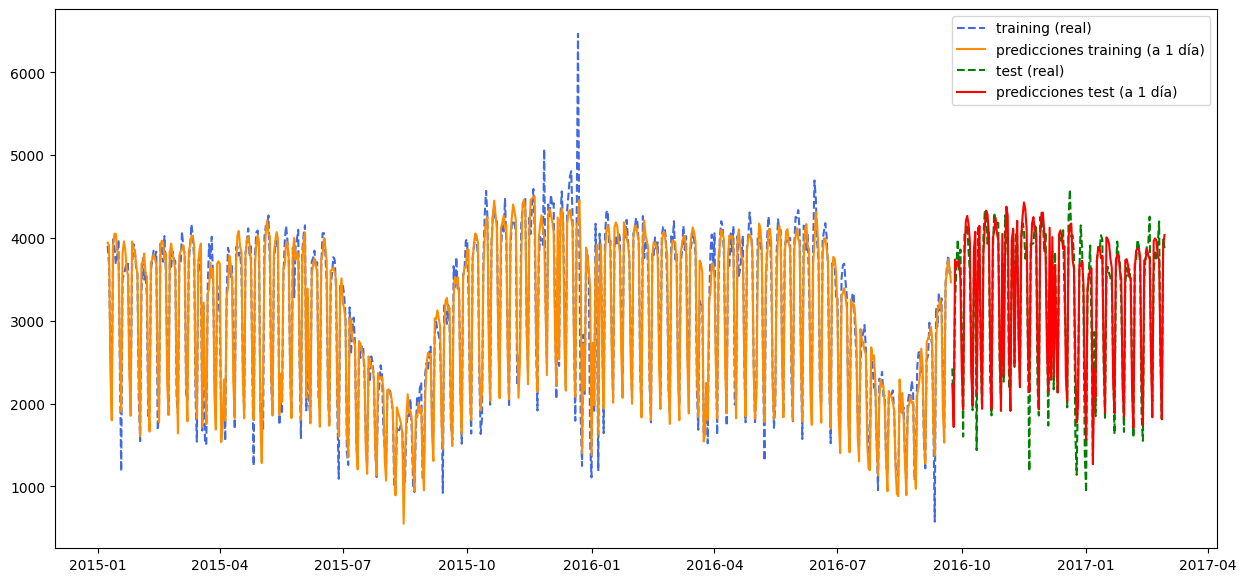

In [141]:
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, "--", c="royalblue", label="training (real)")
plt.plot(fechas_train, target_train_pred, c="darkorange", label="predicciones training (a 1 día)")
plt.plot(fechas_test, target_test, "--", c="green", label="test (real)")
plt.plot(fechas_test, target_test_pred, c="red", label="predicciones test (a 1 día)")
plt.legend();

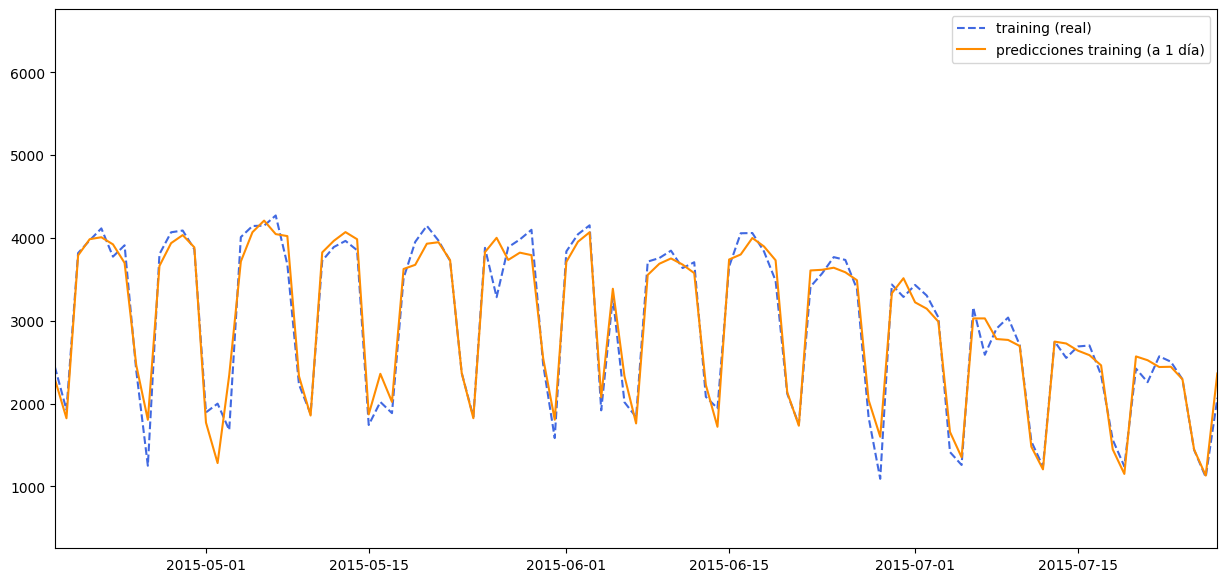

In [142]:
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, "--", c="royalblue", label="training (real)")
plt.plot(fechas_train, target_train_pred, c="darkorange", label="predicciones training (a 1 día)")
plt.xlim([fechas_train[100], fechas_train[200]])
plt.legend();

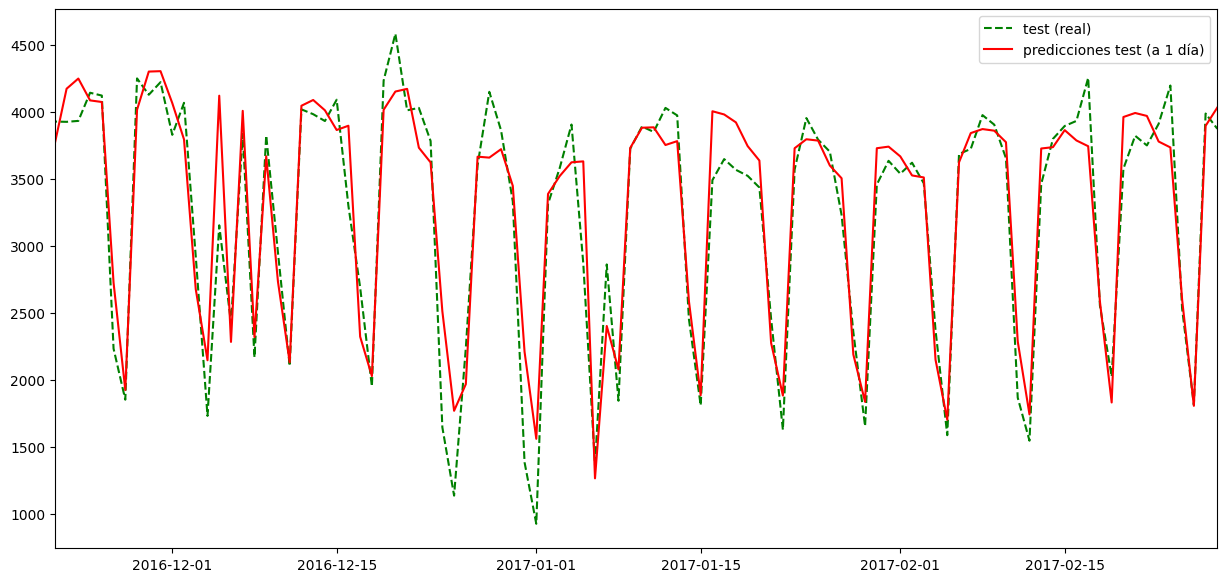

In [143]:
plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, "--", c="green", label="test (real)")
plt.plot(fechas_test, target_test_pred, c="red", label="predicciones test (a 1 día)")
plt.xlim([fechas_test[-100], fechas_test[-1]])
plt.legend();

In [144]:
R2(target_train, target_train_pred)

0.9280675901747061

In [145]:
R2(target_test, target_test_pred)

0.890838805696399

## Interpretación embeddings

In [92]:
embeddings_mes = model.get_layer("embedding_mes").get_weights()[0]
embeddings_mes

array([[ 0.19642533,  0.01303368],
       [ 0.0471845 ,  0.0722966 ],
       [-0.02692143,  0.10951321],
       [-0.12725501,  0.21447884],
       [-0.00058108,  0.20406502],
       [-0.09076368,  0.13964537],
       [-0.23888502, -0.21222305],
       [-0.23038591, -0.41550744],
       [ 0.05415337, -0.21002163],
       [ 0.03483732,  0.2688315 ],
       [ 0.17523937,  0.32319823],
       [ 0.29868177,  0.04219964]], dtype=float32)

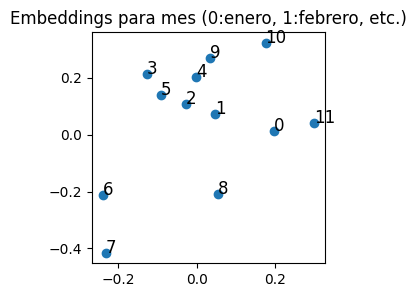

In [93]:
plt.figure(figsize=(3,3))
plt.plot(embeddings_mes[:,0], embeddings_mes[:,1], "o")
for i,coords in enumerate(embeddings_mes):
  plt.text(coords[0], coords[1], i, fontsize=12)
plt.title("Embeddings para mes (0:enero, 1:febrero, etc.)");

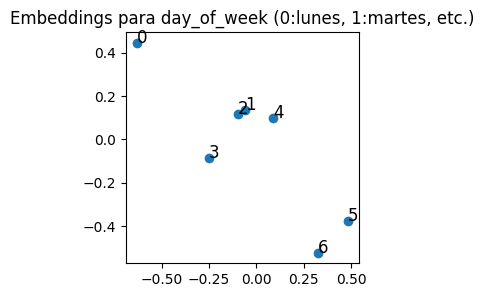

In [94]:
embeddings_day_of_week = model.get_layer("embedding_day_of_week").get_weights()[0]

plt.figure(figsize=(3,3))
plt.plot(embeddings_day_of_week[:,0], embeddings_day_of_week[:,1], "o")
for i,coords in enumerate(embeddings_day_of_week):
  plt.text(coords[0], coords[1], i, fontsize=12)
plt.title("Embeddings para day_of_week (0:lunes, 1:martes, etc.)");

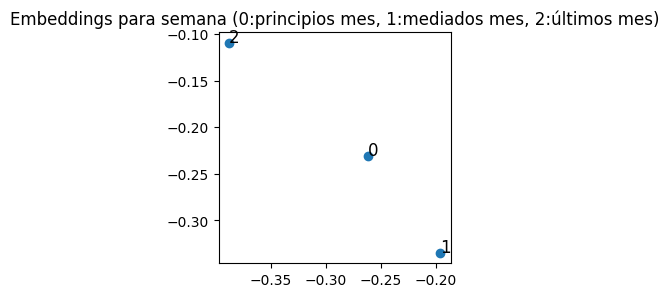

In [95]:
embeddings_semana = model.get_layer("embedding_semana").get_weights()[0]

plt.figure(figsize=(3,3))
plt.plot(embeddings_semana[:,0], embeddings_semana[:,1], "o")
for i,coords in enumerate(embeddings_semana):
  plt.text(coords[0], coords[1], i, fontsize=12)
plt.title("Embeddings para semana (0:principios mes, 1:mediados mes, 2:últimos mes)");

In [96]:
def multistep(model, Xs):
    salidas = []
    ventana_target_transf = Xs["target_transf"][:1].copy()
    for i in range(len(Xs["target_transf"])):
        z = model.predict(
            {
              "target_transf":ventana_target_transf,
              "festivo":Xs["festivo"][i:(i+1)],
              "mes":Xs["mes"][i:(i+1)],
              "semana":Xs["semana"][i:(i+1)],
              "day_of_week":Xs["day_of_week"][i:(i+1)]
            }, verbose=0
        )[0][0]
        salidas.append(inverse_transform(z).round())
        # preparo la nueva ventana de la variable endógena:
        ventana_target_transf[0][:-1] = ventana_target_transf[0][1:].copy() # desplazo a la izquierda datos de la ventana
        ventana_target_transf[0][-1] = z

    return salidas

In [97]:
# datos para predicción multi-step:
datos_test2 = {
    "target_transf": X0_test.copy(),
    "festivo": X1_test,
    "mes": X2_test,
    "semana": X3_test,
    "day_of_week": X4_test
}

datos_test2["target_transf"][1:] = NAN

In [98]:
datos_test2["target_transf"][:1]

array([[[-0.7023821 ],
        [-1.29407271],
        [ 0.43350555],
        [ 0.63337429],
        [ 0.76200268],
        [ 0.54630276],
        [ 0.57598623]]])

In [99]:
len(datos_test2["target_transf"])

158

In [100]:
pred_multistep_test = multistep(model, datos_test2)

In [101]:
len(pred_multistep_test)

158

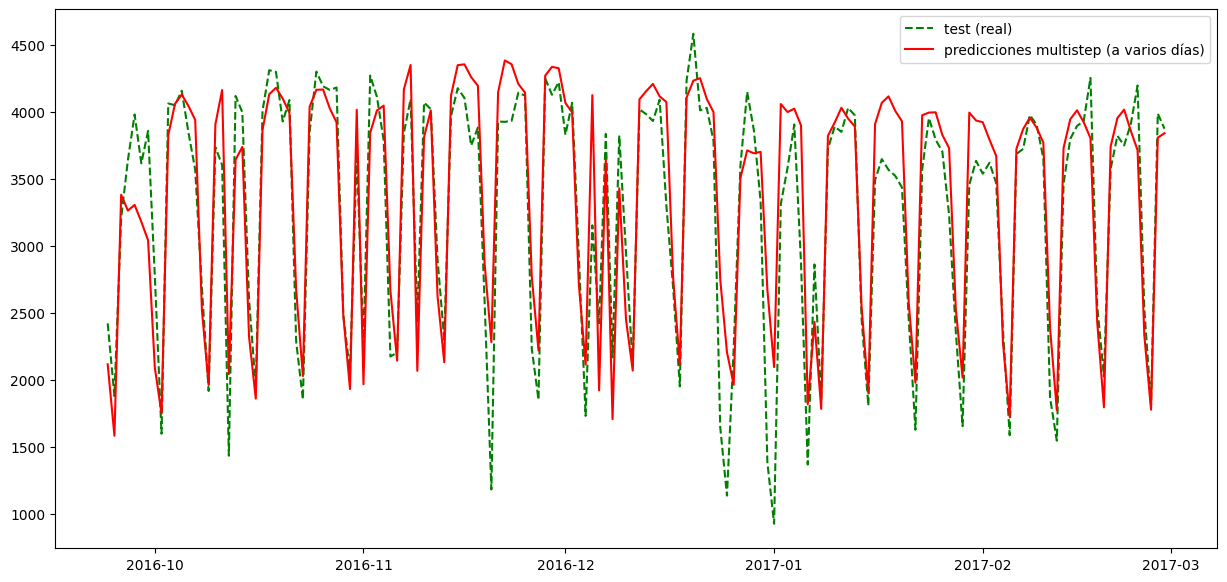

In [102]:
plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, "--", c="green", label="test (real)")
plt.plot(fechas_test, pred_multistep_test, c="red", label="predicciones multistep (a varios días)")
#plt.xlim([fechas_test[-100], fechas_test[-1]])
plt.legend();

In [103]:
R2(target_test, pred_multistep_test)

0.8261444959725688

In [104]:
import pickle

data_aux_model = {
    "fecha": "2023-07-26",
    "comentarios": "media y std utilizada para normalizar en modelo con embeddings",
    "media_pasajeros": media_pasajeros,
    "std_pasajeros": std_pasajeros,
    "W": W
}

with open("data_aux_model_con_embeddings.pkl", "bw") as f:
    pickle.dump(data_aux_model, f)

In [105]:
# En producción lo cargaría así:

import pickle

with open("data_aux_model_con_embeddings.pkl", "br") as f:
    data_aux_model2 = pickle.load(f)

In [106]:
data_aux_model2

{'fecha': '2023-07-26',
 'comentarios': 'media y std utilizada para normalizar en modelo con embeddings',
 'media_pasajeros': 3014.871835443038,
 'std_pasajeros': 1010.6633275915394,
 'W': 7}

In [107]:
media_pasajeros, std_pasajeros

(3014.871835443038, 1010.6633275915394)

# Explicabilidad (XAI)

Funciones auxiliares:

In [146]:
startbold = '\033[1m'
endbold = '\033[0m'

In [147]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, _tree

# based and extended from:
# http://scikit-learn-general.narkive.com/qDWR2kGK/how-to-extract-the-decision-tree-rule-of-each-leaf-node-into-pandas-dataframe-query


def get_rules_from_regression_tree(clf, feature_names, X, y, binary_features=[], start_bold="", end_bold=""):
    from sklearn.tree._tree import TREE_LEAF

    rules = {}

    def recurse(node_id, aux_rules=[]):
        left = clf.tree_.children_left[node_id]
        right = clf.tree_.children_right[node_id]

        #Check if this is a decision node
        if left != TREE_LEAF:
            feature = feature_names[clf.tree_.feature[node_id]]
            bold_name = start_bold+feature+end_bold
            if feature not in binary_features:
                new_rule = "(" + bold_name + " {0} " + "%.4f" % clf.tree_.threshold[node_id] + ")"
                recurse(left, aux_rules + [new_rule.format('<=')])
                recurse(right, aux_rules + [new_rule.format('>')])
            else:
                new_rule = "(" + bold_name + " == {})"
                recurse(left, aux_rules + [new_rule.format(0)])
                recurse(right, aux_rules + [new_rule.format(1)])

            return
        else: # Leaf
            rules[node_id] = " and ".join(aux_rules)
            return

    recurse(node_id=0)
    classification_leafs = clf.apply(X)
    extended_rules = {}
    for k,v in rules.items():
        aux = y[classification_leafs == k]
        extended_rules[k] = [v, aux.mean()]

    return extended_rules

## **Interpretación del LSTM desde el punto de vista de predicción del número de pasajeros**

Para entender el LSTM, que no es interpretable, montamos un modelo interpretable, en este caso un árbol de decisión, que explique la salida del LSTM en función de las entradas. A este modelo interpretable se le llama "modelo surrogado" (surrogate model).

In [157]:
data

,mes,festivo,npasajeros,semana_mes,day_of_week
fecha,,,,,
2015-01-01,1,1,1125,0,3
2015-01-02,1,0,3592,0,4
2015-01-03,1,0,3001,0,5
2015-01-04,1,0,2260,0,6
2015-01-05,1,0,2767,0,0
...,...,...,...,...,...
2017-02-24,2,0,4199,2,4
2017-02-25,2,0,2534,2,5
2017-02-26,2,0,1816,2,6


In [181]:
# Preparación del dataset para obtener la explicación con un árbol
# Cada línea va a ser un registro diferente para el árbol

pd.options.display.max_columns = None
W_XAI = 1

df2 = data.copy()
fechas_aux = df2.index

for i in range(1,1+W_XAI):
    print(i)
    aux = "y(-{})".format(i)
    df2[aux] = NAN
    df2.loc[fechas_aux[i:], aux] = df2.loc[fechas_aux[:-i], "npasajeros"].values

for i,m in enumerate(["ene","feb","mar","abr","may","jun","jul","ago","sep","oct","nov","dic"]):
    df2[m] = 1*(df2["mes"] == (i+1))
df2.drop("mes", axis=1, inplace=True)

for i,d in enumerate(["lun","martes","mie","jue","vie","sab","dom"]):
    df2[d] = 1*(df2["day_of_week"] == i)
df2.drop("day_of_week", axis=1, inplace=True)

df2[:10]

1


,festivo,npasajeros,semana_mes,y(-1),ene,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,lun,martes,mie,jue,vie,sab,dom
fecha,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,1,1125,0,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2015-01-02,0,3592,0,1125.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2015-01-03,0,3001,0,3592.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2015-01-04,0,2260,0,3001.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2015-01-05,0,2767,0,2260.0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2015-01-06,1,1342,0,2767.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2015-01-07,0,3867,0,1342.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2015-01-08,0,3904,1,3867.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2015-01-09,0,3678,1,3904.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [182]:
len(X0), len(df2), W

(790, 790, 7)

In [183]:
# Todo el dataset (training + test): quiero una explicación de cómo funciona
# el LSTM en todos los datos, tanto training como test

datos_XAI = {
    "target_transf": X0[W:],
    "festivo": X1[W:],
    "mes": X2[W:],
    "semana": X3[W:],
    "day_of_week": X4[W:]
}

In [184]:
salidas_LSTM = model.predict(datos_XAI, verbose=0).flatten()
target_pred_LSTM = inverse_transform(salidas_LSTM).round()
target_pred_LSTM[:5]

array([3944., 3901., 2388., 1797., 3902.], dtype=float32)

In [185]:
X_explainab = df2[W:].drop("npasajeros", axis=1)
X_explainab

,festivo,semana_mes,y(-1),ene,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,lun,martes,mie,jue,vie,sab,dom
fecha,,,,,,,,,,,,,,,,,,,,,,
2015-01-08,0,1,3867.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2015-01-09,0,1,3904.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2015-01-10,0,1,3678.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2015-01-11,0,1,2631.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2015-01-12,0,1,2112.0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-24,0,2,3913.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2017-02-25,0,2,4199.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2017-02-26,0,2,2534.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [191]:
target_pred_LSTM[:10]

array([3944., 3901., 2388., 1797., 3902., 4050., 4050., 3843., 3798.,
       2597.], dtype=float32)

In [203]:
objetivo = 0.91 # precisión deseada de la explicación (de 0 a 1; 1: perfecto)
n_hojas = 1
seguir = True
while seguir:
    n_hojas = n_hojas + 1
    explainer = DecisionTreeRegressor(max_leaf_nodes=n_hojas) # max_depth=4)
    explainer.fit(X_explainab, target_pred_LSTM)
    y_surrogated = explainer.predict(X_explainab)
    aux = R2(target_pred_LSTM, y_surrogated)
    print(n_hojas, aux)
    seguir = aux < objetivo

2 0.32860916231698023
3 0.5126452536659157
4 0.6673017938173111
5 0.7115579181993403
6 0.7508758227726202
7 0.7896845225686171
8 0.8214633707803404
9 0.8482786371868986
10 0.8715586332842765
11 0.8850200774615672
12 0.8957955912292588
13 0.9057995348564818
14 0.9150420015209454


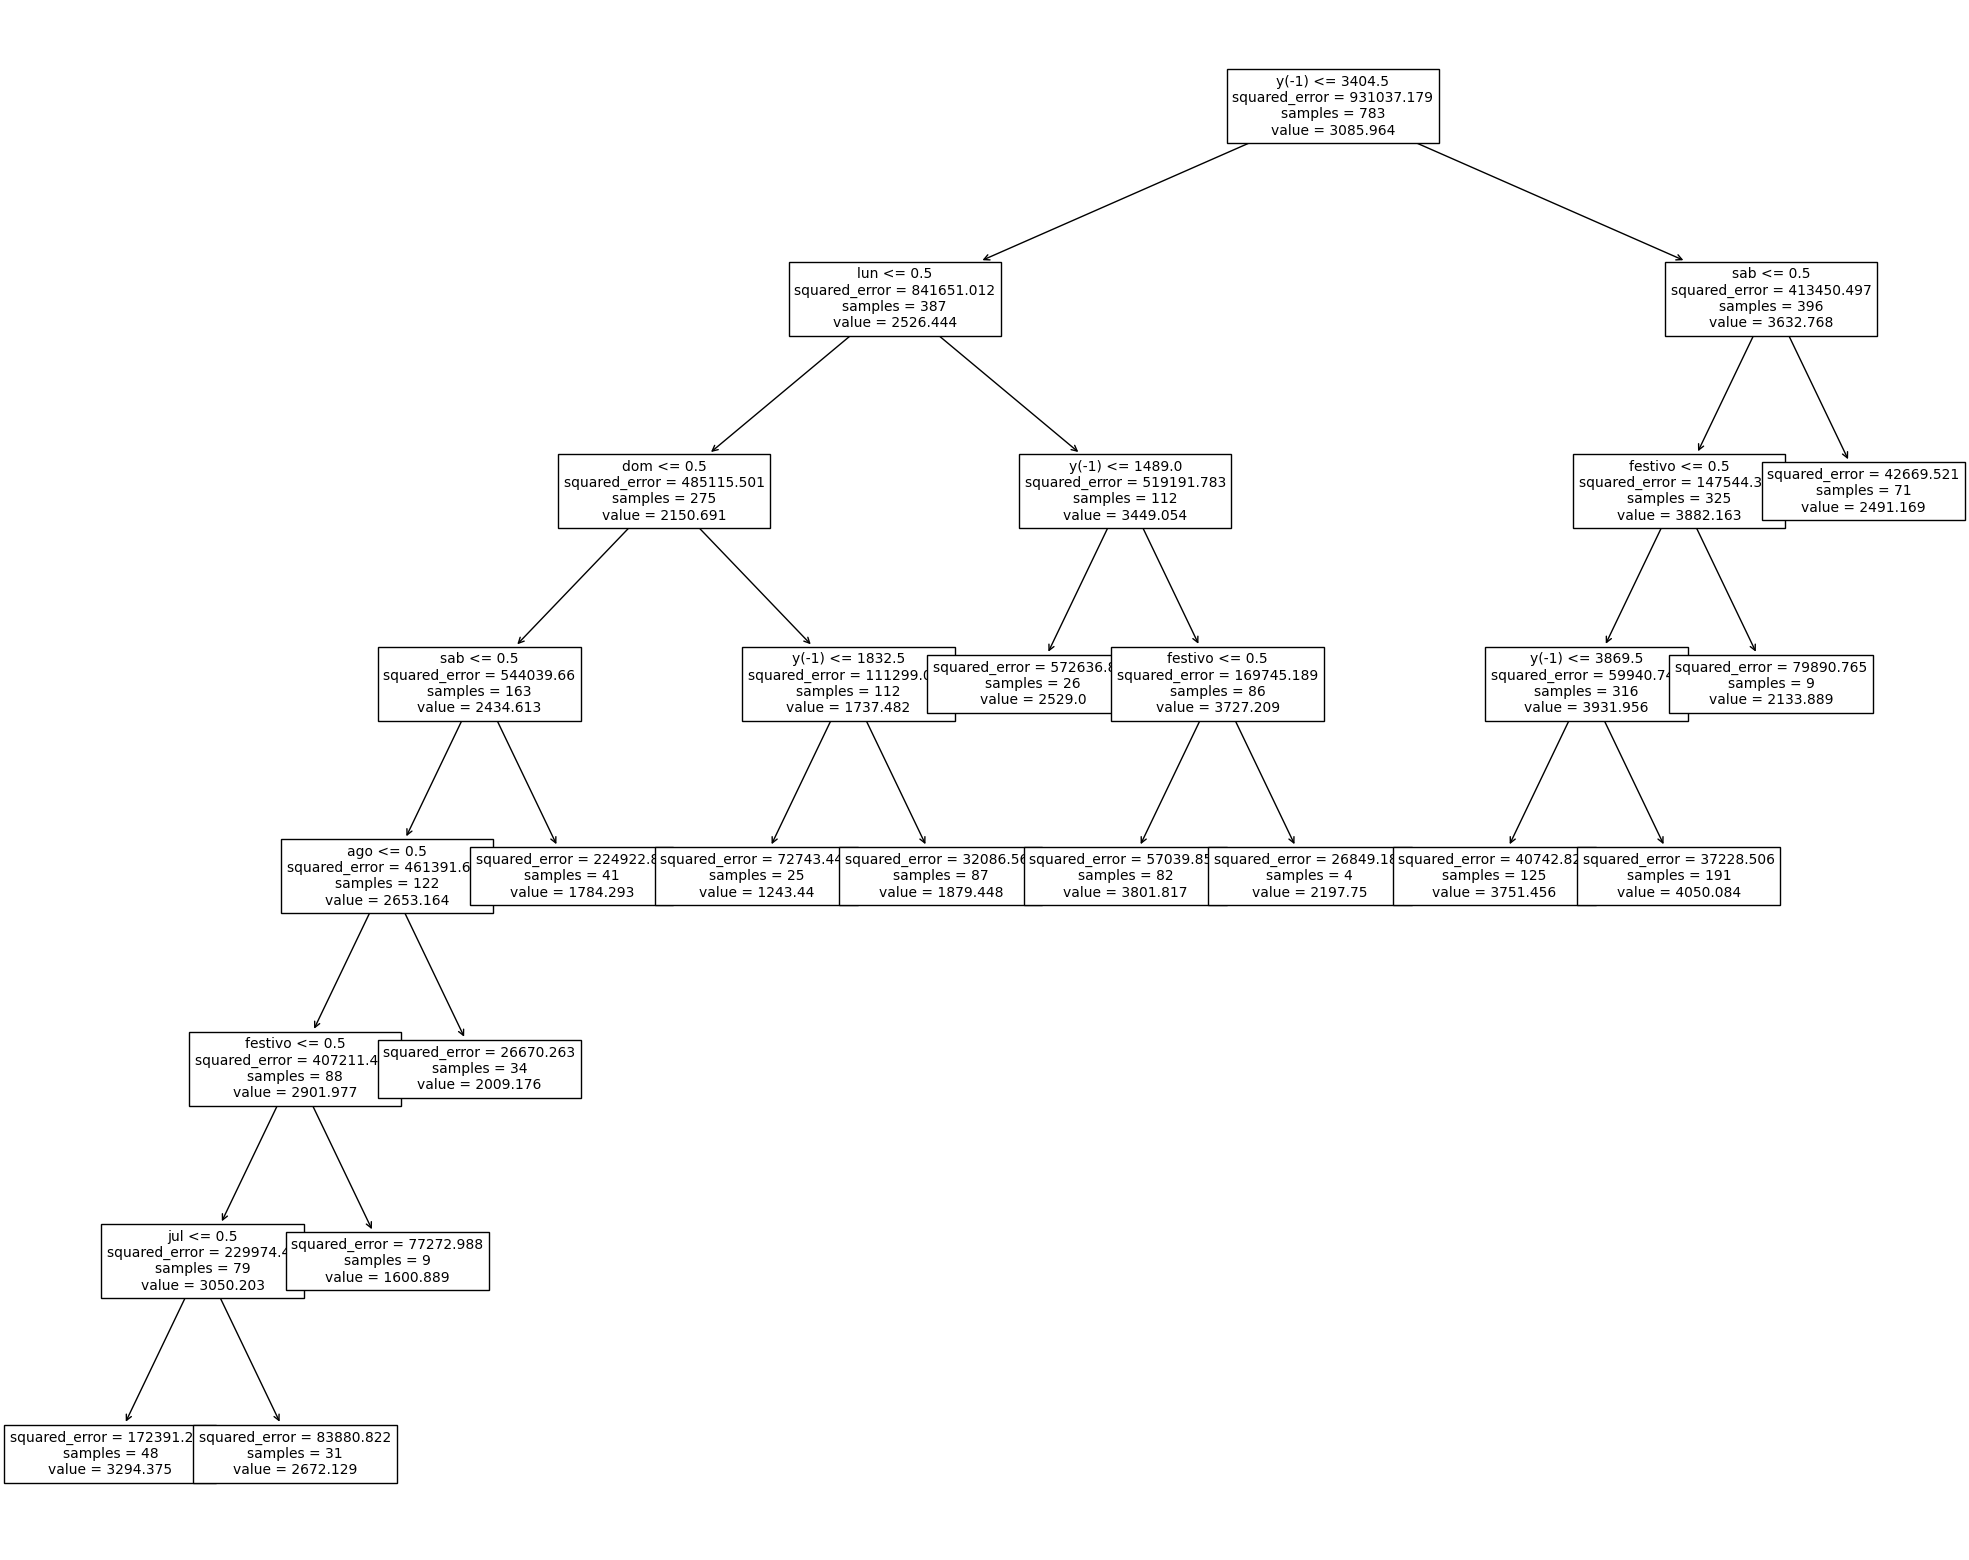

In [204]:
plt.figure(figsize=(25,20))
plot_tree(explainer, feature_names=X_explainab.columns, fontsize=10);

In [205]:
binary_features = [name for name in X_explainab.columns if set(X_explainab[name].tolist()) == {0,1}]

In [206]:
rules = get_rules_from_regression_tree(explainer, X_explainab.columns, X_explainab, target_pred_LSTM,
                                       binary_features=binary_features, start_bold="", end_bold="")

for r in rules:
    rule = rules[r]
    print("IF " + rule[0] + " THEN prediction = {}".format(rule[1]))

IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 0) and (sab == 0) and (ago == 0) and (festivo == 0) and (jul == 0) THEN prediction = 3294.375
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 0) and (sab == 0) and (ago == 0) and (festivo == 0) and (jul == 1) THEN prediction = 2672.129150390625
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 0) and (sab == 0) and (ago == 0) and (festivo == 1) THEN prediction = 1600.888916015625
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 0) and (sab == 0) and (ago == 1) THEN prediction = 2009.176513671875
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 0) and (sab == 1) THEN prediction = 1784.292724609375
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 1) and (y(-1) <= 1832.5000) THEN prediction = 1243.43994140625
IF (y(-1) <= 3404.5000) and (lun == 0) and (dom == 1) and (y(-1) > 1832.5000) THEN prediction = 1879.4482421875
IF (y(-1) <= 3404.5000) and (lun == 1) and (y(-1) <= 1489.0000) THEN prediction = 2529.0
IF (y(-1) <= 3404.5000

In [207]:
# precisión de la explicación (máximo: 1)

y_surrogated = explainer.predict(X_explainab)
R2(target_pred_LSTM, y_surrogated)

0.9150420015209454